<a href="https://colab.research.google.com/github/kleaa-hash/deprivation-spending-analysis/blob/main/02_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Authenticate with Google and connect to BigQuery

from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

client = bigquery.Client(project='deprivation-spending-analysis')
print("Connected to BigQuery successfully")

Connected to BigQuery successfully


In [3]:
# Load the mart table from BigQuery
# This is the core analytical table with 1,733 rows
# One row per local authority per financial year (2019-20 to 2024-25)
query = """
SELECT *
FROM `deprivation-spending-analysis.spending_analysis_marts.mart_deprivation_spending`
ORDER BY lad_code, financial_year_start
"""

df = client.query(query).to_dataframe()

print(f"Rows loaded: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nFinancial years: {sorted(df['financial_year_start'].unique())}")
print(f"Authorities per year:")
print(df.groupby('financial_year_start')['lad_code'].count())
print(f"\nRegions: {sorted(df['region_name'].unique())}")
print(f"\nAuthority classes: {sorted(df['la_class'].unique())}")

Rows loaded: 1733
Columns: ['year_ending', 'financial_year_start', 'lad_code', 'la_name', 'la_class', 'la_subclass', 'imd_score', 'imd_rank', 'imd_proportion_deprived_10pct', 'net_current_expenditure', 'total_service_expenditure', 'adult_social_care_expenditure', 'childrens_social_care_expenditure', 'population', 'net_current_expenditure_per_capita', 'total_service_expenditure_per_capita', 'adult_social_care_per_capita', 'childrens_social_care_per_capita', 'is_covid_year', 'region_name']

Financial years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Authorities per year:
financial_year_start
2019    289
2020    290
2021    292
2022    292
2023    283
2024    287
Name: lad_code, dtype: int64

Regions: ['East Midlands', 'East of England', 'London', 'North East', 'North West', 'South East', 'South West', 'West Midlands', 'Yorkshire and The Humber']

Authority classes: ['London', 'Met District', 'Shire District', 'Unitary Authority']


In [4]:
# Descriptive statistics for the key variables
# This gives us a first look at the data before running any models
# Important for spotting outliers or unexpected values

print("=== KEY VARIABLE SUMMARY ===\n")

key_vars = [
    'imd_score',
    'net_current_expenditure_per_capita',
    'total_service_expenditure_per_capita',
    'adult_social_care_per_capita',
    'childrens_social_care_per_capita',
    'population'
]

print(df[key_vars].describe().round(2))

print("\n=== SPENDING BY REGION (average net current expenditure per capita) ===\n")
print(df.groupby('region_name')['net_current_expenditure_per_capita'].mean().round(2).sort_values(ascending=False))

print("\n=== SPENDING BY AUTHORITY CLASS ===\n")
print(df.groupby('la_class')['net_current_expenditure_per_capita'].mean().round(2).sort_values(ascending=False))

print("\n=== DEPRIVATION BY REGION (average IMD score) ===\n")
print(df.groupby('region_name')['imd_score'].mean().round(2).sort_values(ascending=False))

=== KEY VARIABLE SUMMARY ===

       imd_score  net_current_expenditure_per_capita  \
count    1733.00                             1733.00   
mean       20.11                             1149.94   
std         7.96                             1684.89   
min         5.91                              -80.14   
25%        13.75                              319.25   
50%        19.02                              415.26   
75%        25.61                             1852.54   
max        43.47                            29088.94   

       total_service_expenditure_per_capita  adult_social_care_per_capita  \
count                               1733.00                       1733.00   
mean                                 908.85                        162.40   
std                                 1638.78                        189.84   
min                                  -77.96                         -3.05   
25%                                  142.44                          0.00   
50%

In [5]:
# Investigate unexpected values before running regression
# Two issues flagged in descriptive statistics:
# 1. Negative per capita spending values
# 2. Extremely high maximum value (£29,088 per capita)

print("=== NEGATIVE NET CURRENT EXPENDITURE PER CAPITA ===")
negative_rows = df[df['net_current_expenditure_per_capita'] < 0]
print(f"Number of rows with negative values: {len(negative_rows)}")
print(negative_rows[['lad_code', 'la_name', 'financial_year_start',
                       'net_current_expenditure_per_capita',
                       'la_class', 'region_name']].to_string())

print("\n=== EXTREMELY HIGH SPENDING (above £5,000 per capita) ===")
high_rows = df[df['net_current_expenditure_per_capita'] > 5000]
print(f"Number of rows above £5,000: {len(high_rows)}")
print(high_rows[['lad_code', 'la_name', 'financial_year_start',
                  'net_current_expenditure_per_capita',
                  'la_class', 'region_name']].to_string())

=== NEGATIVE NET CURRENT EXPENDITURE PER CAPITA ===
Number of rows with negative values: 4
       lad_code     la_name  financial_year_start  net_current_expenditure_per_capita        la_class region_name
1150  E07000213  Spelthorne                  2019                              -68.88  Shire District  South East
1151  E07000213  Spelthorne                  2020                              -32.56  Shire District  South East
1152  E07000213  Spelthorne                  2021                              -71.16  Shire District  South East
1153  E07000213  Spelthorne                  2022                              -80.14  Shire District  South East

=== EXTREMELY HIGH SPENDING (above £5,000 per capita) ===
Number of rows above £5,000: 6
       lad_code         la_name  financial_year_start  net_current_expenditure_per_capita la_class region_name
1535  E09000001  City of London                  2019                            24972.62   London      London
1536  E09000001  City of Lo

In [6]:
# ============================================================
# PREPARE DATA FOR REGRESSION
# ============================================================
# Two decisions made based on descriptive statistics:
# D20: Retain Spelthorne negative values — real accounting data
# D21: Exclude City of London — extreme outlier due to tiny
#      residential population, not representative of need-based spending
# ============================================================

# Exclude City of London
df_reg = df[df['lad_code'] != 'E09000001'].copy()

print(f"Rows after excluding City of London: {len(df_reg)}")
print(f"City of London rows removed: {len(df) - len(df_reg)}")

# Check the dependent variable distribution after exclusion
print(f"\nNet current expenditure per capita after exclusion:")
print(f"  Mean: £{df_reg['net_current_expenditure_per_capita'].mean():.2f}")
print(f"  Median: £{df_reg['net_current_expenditure_per_capita'].median():.2f}")
print(f"  Max: £{df_reg['net_current_expenditure_per_capita'].max():.2f}")
print(f"  Min: £{df_reg['net_current_expenditure_per_capita'].min():.2f}")

# Convert boolean to integer for regression
df_reg['is_covid_year_int'] = df_reg['is_covid_year'].astype(int)

print(f"\nData ready for regression. {len(df_reg)} observations.")

Rows after excluding City of London: 1727
City of London rows removed: 6

Net current expenditure per capita after exclusion:
  Mean: £1065.71
  Median: £414.03
  Max: £4853.34
  Min: £-80.14

Data ready for regression. 1727 observations.


In [7]:
# ============================================================
# MAIN REGRESSION — Model 1
# ============================================================
# Dependent variable: net_current_expenditure_per_capita
# Primary independent variable: imd_score
# Controls: is_covid_year, la_class dummies, region_name dummies
# Standard errors clustered by authority (lad_code)
# Pre-stated criteria (Decision D15):
#   Positive relationship if imd_score positive and p < 0.05
#   Weak/absent if not significant or R-squared < 0.10
# ============================================================

# Run OLS regression with categorical dummies
model1 = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + is_covid_year_int + C(la_class) + C(region_name)',
    data=df_reg
).fit(cov_type='cluster', cov_kwds={'groups': df_reg['lad_code']})

print(model1.summary())

                                    OLS Regression Results                                    
Dep. Variable:     net_current_expenditure_per_capita   R-squared:                       0.918
Model:                                            OLS   Adj. R-squared:                  0.918
Method:                                 Least Squares   F-statistic:                     1226.
Date:                                Wed, 26 Aug 2026   Prob (F-statistic):          2.55e-247
Time:                                        09:09:59   Log-Likelihood:                -12007.
No. Observations:                                1727   AIC:                         2.404e+04
Df Residuals:                                    1714   BIC:                         2.411e+04
Df Model:                                          12                                         
Covariance Type:                              cluster                                         
                                                 c

In [8]:
# ============================================================
# CHECK MULTICOLLINEARITY
# ============================================================
# The regression warned about possible multicollinearity
# VIF above 5 is moderate concern, above 10 is serious
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Create the design matrix manually for VIF calculation
X = pd.get_dummies(df_reg[['imd_score', 'is_covid_year_int', 'la_class', 'region_name']],
                   drop_first=True, dtype=float)
X['intercept'] = 1

vif_data = pd.DataFrame()
vif_data['variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("VIF values (above 5 = moderate concern, above 10 = serious):")
print(vif_data.sort_values('VIF', ascending=False).to_string())

VIF values (above 5 = moderate concern, above 10 = serious):
                                variable       VIF
3                la_class_Shire District       inf
2                  la_class_Met District       inf
4             la_class_Unitary Authority       inf
6                     region_name_London       inf
9                 region_name_South East  2.307028
8                 region_name_North West  2.153620
5            region_name_East of England  1.963657
11             region_name_West Midlands  1.751632
12  region_name_Yorkshire and The Humber  1.740490
10                region_name_South West  1.703520
7                 region_name_North East  1.557311
0                              imd_score  1.498092
1                      is_covid_year_int  1.000174
13                             intercept  0.000000


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.13/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [9]:
# ============================================================
# MODEL 2 — Remove la_class to fix perfect multicollinearity
# ============================================================
# Decision D22: la_class and region_name are perfectly collinear
# for London authorities. Remove la_class, retain region_name.
# Original model retained as Model 1a in sensitivity analysis.
# ============================================================

model2 = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + is_covid_year_int + C(region_name)',
    data=df_reg
).fit(cov_type='cluster', cov_kwds={'groups': df_reg['lad_code']})

print(model2.summary())
print(f"\nimd_score coefficient: {model2.params['imd_score']:.4f}")
print(f"imd_score p-value: {model2.pvalues['imd_score']:.4f}")
print(f"R-squared: {model2.rsquared:.4f}")

                                    OLS Regression Results                                    
Dep. Variable:     net_current_expenditure_per_capita   R-squared:                       0.562
Model:                                            OLS   Adj. R-squared:                  0.560
Method:                                 Least Squares   F-statistic:                     106.3
Date:                                Wed, 26 Aug 2026   Prob (F-statistic):           1.74e-91
Time:                                        09:09:59   Log-Likelihood:                -13456.
No. Observations:                                1727   AIC:                         2.693e+04
Df Residuals:                                    1716   BIC:                         2.699e+04
Df Model:                                          10                                         
Covariance Type:                              cluster                                         
                                                 c

In [10]:
# ============================================================
# INVESTIGATE NEGATIVE COVID YEAR COEFFICIENT
# ============================================================
# COVID years (2020-21, 2021-22) show LOWER spending per capita
# This is counterintuitive — investigate why
# ============================================================

print("Average spending by year:")
yearly = df_reg.groupby('financial_year_start')['net_current_expenditure_per_capita'].agg(['mean', 'median']).round(2)
yearly['is_covid'] = yearly.index.isin([2020, 2021])
print(yearly)

print("\nAverage spending COVID vs non-COVID years:")
print(df_reg.groupby('is_covid_year')['net_current_expenditure_per_capita'].agg(['mean', 'median']).round(2))

Average spending by year:
                         mean  median  is_covid
financial_year_start                           
2019                   961.11  387.26     False
2020                  1029.79  447.18      True
2021                  1018.43  394.03      True
2022                  1045.84  391.35     False
2023                  1150.45  418.72     False
2024                  1192.11  427.24     False

Average spending COVID vs non-COVID years:
                  mean  median
is_covid_year                 
False          1086.76  406.95
True           1024.09  431.56


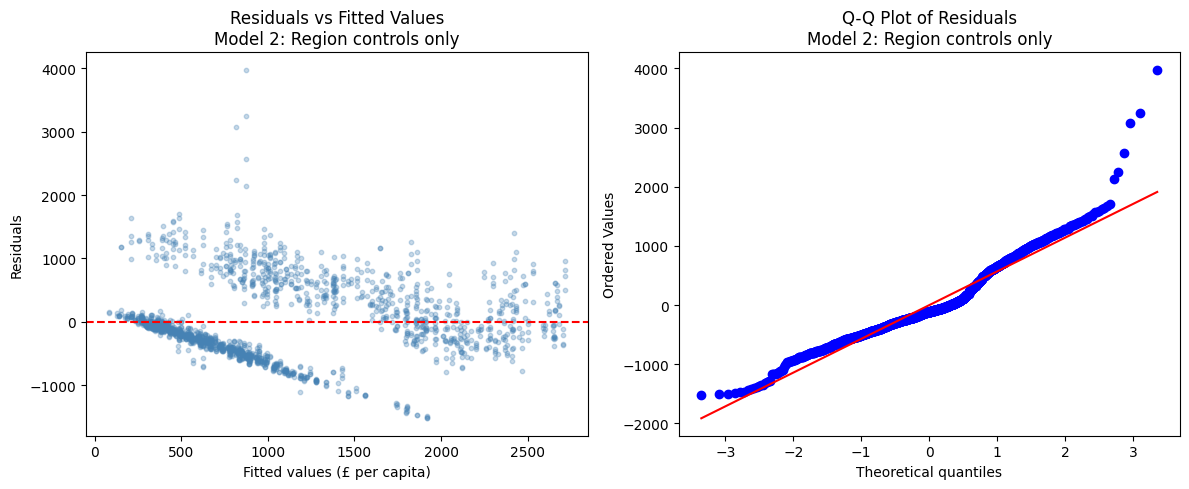

Diagnostic plots saved


In [11]:
# ============================================================
# DIAGNOSTIC PLOTS FOR MODEL 2
# ============================================================
# Check regression assumptions:
# 1. Residuals vs fitted (homoscedasticity)
# 2. Q-Q plot (normality of residuals)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs fitted
fitted = model2.fittedvalues
residuals = model2.resid

axes[0].scatter(fitted, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values (£ per capita)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values\nModel 2: Region controls only')

# Q-Q plot
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals\nModel 2: Region controls only')

plt.tight_layout()
plt.savefig('model2_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Diagnostic plots saved")


In [12]:
# ============================================================
# SENSITIVITY ANALYSIS 1 — Exclude COVID years
# ============================================================
# Decision D6: main model includes COVID years with boolean control
# This sensitivity tests whether excluding them changes the
# deprivation coefficient materially
# ============================================================

df_no_covid = df_reg[df_reg['is_covid_year'] == False].copy()
print(f"Observations excluding COVID years: {len(df_no_covid)}")

model_s1 = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + C(region_name)',
    data=df_no_covid
).fit(cov_type='cluster', cov_kwds={'groups': df_no_covid['lad_code']})

print(f"\nSensitivity 1 — COVID years excluded:")
print(f"imd_score coefficient: {model_s1.params['imd_score']:.4f}")
print(f"imd_score p-value: {model_s1.pvalues['imd_score']:.4f}")
print(f"R-squared: {model_s1.rsquared:.4f}")

Observations excluding COVID years: 1147

Sensitivity 1 — COVID years excluded:
imd_score coefficient: 36.4764
imd_score p-value: 0.0000
R-squared: 0.5556


In [13]:
# ============================================================
# SENSITIVITY ANALYSES 2, 3, 4
# ============================================================
# S2: RS_totsx_net_exp (line 699) instead of RS_netcurrtot_net_exp
# S3: Adult social care per capita as dependent variable
# S4: Children's social care per capita as dependent variable
# ============================================================

sensitivities = {
    'S2 - Total service expenditure per capita': 'total_service_expenditure_per_capita',
    'S3 - Adult social care per capita': 'adult_social_care_per_capita',
    'S4 - Children social care per capita': 'childrens_social_care_per_capita'
}

for name, dep_var in sensitivities.items():
    model_s = smf.ols(
        formula=f'{dep_var} ~ imd_score + is_covid_year_int + C(region_name)',
        data=df_reg
    ).fit(cov_type='cluster', cov_kwds={'groups': df_reg['lad_code']})

    print(f"\n{name}:")
    print(f"  imd_score coefficient: {model_s.params['imd_score']:.4f}")
    print(f"  imd_score p-value: {model_s.pvalues['imd_score']:.4f}")
    print(f"  R-squared: {model_s.rsquared:.4f}")


S2 - Total service expenditure per capita:
  imd_score coefficient: 28.1740
  imd_score p-value: 0.0000
  R-squared: 0.5003

S3 - Adult social care per capita:
  imd_score coefficient: 5.4665
  imd_score p-value: 0.0000
  R-squared: 0.4293

S4 - Children social care per capita:
  imd_score coefficient: 5.8818
  imd_score p-value: 0.0000
  R-squared: 0.4990


In [14]:
# ============================================================
# SENSITIVITY ANALYSIS 1 — Exclude COVID years
# ============================================================
# Decision D6: main model includes COVID years with boolean control
# This sensitivity tests whether excluding them changes the
# deprivation coefficient materially
# ============================================================

df_no_covid = df_reg[df_reg['is_covid_year'] == False].copy()
print(f"Observations excluding COVID years: {len(df_no_covid)}")

model_s1 = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + C(region_name)',
    data=df_no_covid
).fit(cov_type='cluster', cov_kwds={'groups': df_no_covid['lad_code']})

print(f"\nSensitivity 1 — COVID years excluded:")
print(f"imd_score coefficient: {model_s1.params['imd_score']:.4f}")
print(f"imd_score p-value: {model_s1.pvalues['imd_score']:.4f}")
print(f"R-squared: {model_s1.rsquared:.4f}")

Observations excluding COVID years: 1147

Sensitivity 1 — COVID years excluded:
imd_score coefficient: 36.4764
imd_score p-value: 0.0000
R-squared: 0.5556


In [15]:
# ============================================================
# RANDOM FOREST MODEL
# ============================================================
# Random Forest captures non-linear relationships that OLS misses
# Feature set mirrors Model 2 exactly for direct comparability
# Decision D24: la_class excluded to avoid SHAP dilution
# 500 trees gives stable feature importance estimates
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import shap

# Create dummy variables for region — same as Model 2
df_rf = pd.get_dummies(
    df_reg[['imd_score', 'is_covid_year_int', 'region_name',
            'net_current_expenditure_per_capita', 'lad_code', 'la_name']],
    columns=['region_name'],
    drop_first=True,
    dtype=float
)

# Define features and target
feature_cols = [c for c in df_rf.columns if c not in
                ['net_current_expenditure_per_capita', 'lad_code', 'la_name']]
X = df_rf[feature_cols]
y = df_rf['net_current_expenditure_per_capita']

print(f"Features used: {feature_cols}")
print(f"Observations: {len(X)}")

# Split into train and test sets
# Using 80/20 split — standard for this size dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
# 500 trees for stable estimates, random_state for reproducibility
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1  # use all available CPU cores
)
rf_model.fit(X_train, y_train)

# Evaluate on test set
y_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, y_pred)

print(f"\nRandom Forest R-squared on test set: {rf_r2:.4f}")
print(f"OLS Model 2 R-squared for comparison: 0.5624")

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature importance ranking:")
print(importance_df.to_string())

Features used: ['imd_score', 'is_covid_year_int', 'region_name_East of England', 'region_name_London', 'region_name_North East', 'region_name_North West', 'region_name_South East', 'region_name_South West', 'region_name_West Midlands', 'region_name_Yorkshire and The Humber']
Observations: 1727

Random Forest R-squared on test set: 0.9354
OLS Model 2 R-squared for comparison: 0.5624

Feature importance ranking:
                                feature  importance
0                             imd_score    0.579681
3                    region_name_London    0.265956
4                region_name_North East    0.028447
9  region_name_Yorkshire and The Humber    0.026418
2           region_name_East of England    0.024611
6                region_name_South East    0.023195
5                region_name_North West    0.019254
7                region_name_South West    0.018686
8             region_name_West Midlands    0.008422
1                     is_covid_year_int    0.005331


SHAP values calculated for 1727 observations
Features: ['imd_score', 'is_covid_year_int', 'region_name_East of England', 'region_name_London', 'region_name_North East', 'region_name_North West', 'region_name_South East', 'region_name_South West', 'region_name_West Midlands', 'region_name_Yorkshire and The Humber']


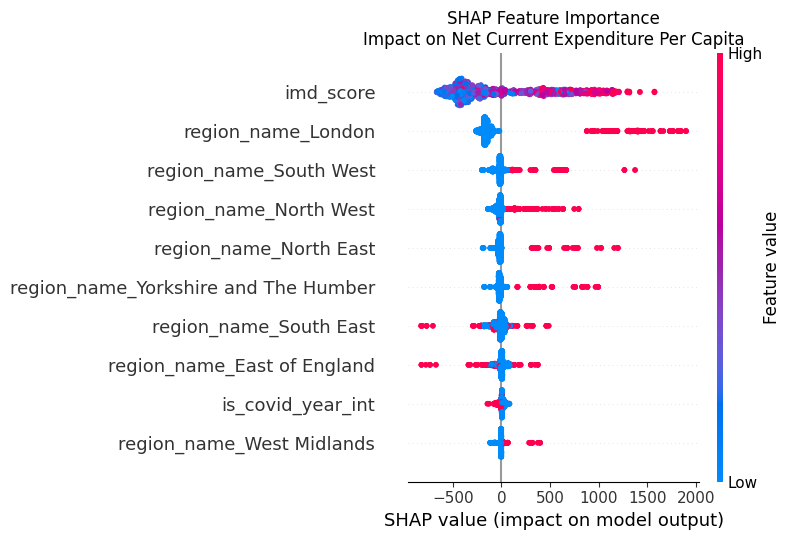

SHAP summary plot saved


In [16]:
# ============================================================
# SHAP VALUES — Individual Authority Explanation
# ============================================================
# SHAP explains WHY the RF predicted what it did for each
# authority — which features pushed the prediction up or down
# This partially addresses Busuioc's Explanation dimension
# for technically literate audiences
# Decision D24: SHAP via TreeExplainer for RF models
# ============================================================

# Calculate SHAP values using TreeExplainer
# TreeExplainer is exact and fast for Random Forest models
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X)

print(f"SHAP values calculated for {len(shap_values)} observations")
print(f"Features: {feature_cols}")

# Summary plot — shows overall feature importance via SHAP
shap.summary_plot(shap_values, X, feature_names=feature_cols, show=False)
plt.title('SHAP Feature Importance\nImpact on Net Current Expenditure Per Capita')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved")

In [17]:
print(len(X))


1727


In [18]:
print(f"Random Forest R-squared on test set: {rf_r2:.4f}")

Random Forest R-squared on test set: 0.9354


In [19]:
# ============================================================
# RANDOM FOREST CROSS-VALIDATION CHECK
# ============================================================
# Single test set R-squared of 0.935 could reflect overfitting
# Cross-validation gives more reliable estimate of generalisation
# Using 5-fold CV — standard for this dataset size
# ============================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model, X, y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print(f"5-fold CV R-squared scores: {cv_scores.round(4)}")
print(f"Mean CV R-squared: {cv_scores.mean():.4f}")
print(f"Std CV R-squared: {cv_scores.std():.4f}")
print(f"\nFor comparison:")
print(f"Single test set R-squared: 0.9354")
print(f"OLS Model 2 R-squared: 0.5624")

5-fold CV R-squared scores: [  -9.1934  -16.9257 -183.0525   -1.1636   -7.4014]
Mean CV R-squared: -43.5473
Std CV R-squared: 69.9335

For comparison:
Single test set R-squared: 0.9354
OLS Model 2 R-squared: 0.5624


In [20]:
# ============================================================
# RANDOM FOREST — CORRECTED WITH GROUP K-FOLD CV
# ============================================================
# Standard CV leaks data because same authority appears in
# both train and test sets across different years
# Group k-fold holds out ALL years for each authority
# This gives honest estimate of out-of-sample performance
# ============================================================

from sklearn.model_selection import GroupKFold, cross_val_score

# Use lad_code as the grouping variable
# Each fold holds out all observations for a set of authorities
groups = df_rf['lad_code']

gkf = GroupKFold(n_splits=5)

cv_scores_group = cross_val_score(
    rf_model, X, y,
    cv=gkf,
    groups=groups,
    scoring='r2',
    n_jobs=-1
)

print(f"Group K-Fold CV R-squared scores: {cv_scores_group.round(4)}")
print(f"Mean Group CV R-squared: {cv_scores_group.mean():.4f}")
print(f"Std Group CV R-squared: {cv_scores_group.std():.4f}")
print(f"\nFor comparison:")
print(f"Standard CV R-squared (misleading): -43.55")
print(f"Single test set R-squared (misleading): 0.9354")
print(f"OLS Model 2 R-squared: 0.5624")

Group K-Fold CV R-squared scores: [0.3363 0.3386 0.2813 0.3247 0.0974]
Mean Group CV R-squared: 0.2757
Std Group CV R-squared: 0.0915

For comparison:
Standard CV R-squared (misleading): -43.55
Single test set R-squared (misleading): 0.9354
OLS Model 2 R-squared: 0.5624


In [24]:
import sys
print(sys.executable)
print(sys.path[:3])

/usr/bin/python3
['/content', '/env/python', '/usr/lib/python313.zip']


In [25]:
import os
print(os.getcwd())
print(os.listdir('.'))

/content
['.config', 'model2_diagnostics.png', 'Local_Authority_Districts_December_2024_Boundaries_UK_BGC_7423724764112241180.geojson', 'shap_summary.png', 'sample_data']


In [26]:
import geopandas as gpd

boundaries = gpd.read_file('/content/Local_Authority_Districts_December_2024_Boundaries_UK_BGC_7423724764112241180.geojson')

print(f"Boundaries loaded: {len(boundaries)} features")
print(f"Columns: {list(boundaries.columns)}")
print(f"\nGeometry type check:")
print(boundaries.geometry.head())

Boundaries loaded: 361 features
Columns: ['FID', 'LAD24CD', 'LAD24NM', 'LAD24NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'GlobalID', 'geometry']

Geometry type check:
0    MULTIPOLYGON (((-1.23001 54.62512, -1.2299 54....
1    MULTIPOLYGON (((-1.27712 54.54791, -1.2772 54....
2    MULTIPOLYGON (((-1.20098 54.57763, -1.20037 54...
3    MULTIPOLYGON (((-1.27493 54.55187, -1.27546 54...
4    POLYGON ((-1.638 54.6172, -1.63767 54.6167, -1...
Name: geometry, dtype: geometry


In [27]:
# ============================================================
# VERIFY BOUNDARY FILE MATCHES YOUR MART DATA
# ============================================================
code_col = 'LAD24CD'  # confirmed from columns list above

# Filter to English authorities only (E06/E07/E08/E09)
boundaries_eng = boundaries[
    boundaries[code_col].str.startswith(('E06', 'E07', 'E08', 'E09'))
].copy()
boundaries_eng = boundaries_eng.rename(columns={code_col: 'lad_code'})

print(f"English authorities in boundary file: {len(boundaries_eng)}")

# Compare against your mart data
your_codes = set(df_reg['lad_code'].unique())
boundary_codes = set(boundaries_eng['lad_code'])

missing_from_boundaries = your_codes - boundary_codes
missing_from_your_data = boundary_codes - your_codes

print(f"\nYour mart codes NOT in boundary file: {len(missing_from_boundaries)}")
if missing_from_boundaries:
    print(missing_from_boundaries)

print(f"\nBoundary codes NOT in your mart data: {len(missing_from_your_data)}")
if missing_from_your_data:
    print(missing_from_your_data)

English authorities in boundary file: 296

Your mart codes NOT in boundary file: 0

Boundary codes NOT in your mart data: 1
{'E09000001'}


In [28]:
# ============================================================
# PREPARE DATA FOR MAPPING
# ============================================================
# Use 2022-23 as snapshot year — avoids Birmingham's absence
# (Birmingham not submitted for 2023-24/2024-25, per D11)
# Merge Model 2 residuals onto the full dataset first
# ============================================================

df_reg['model2_residual'] = model2.resid

df_map = df_reg[df_reg['financial_year_start'] == 2022][
    ['lad_code', 'la_name', 'imd_score', 'net_current_expenditure_per_capita',
     'region_name', 'model2_residual']
].copy()

print(f"Authorities in 2022-23 snapshot: {len(df_map)}")

# Merge with boundaries
gdf_map = boundaries_eng.merge(df_map, on='lad_code', how='inner')
print(f"Matched to boundaries: {len(gdf_map)} authorities")

Authorities in 2022-23 snapshot: 291
Matched to boundaries: 291 authorities


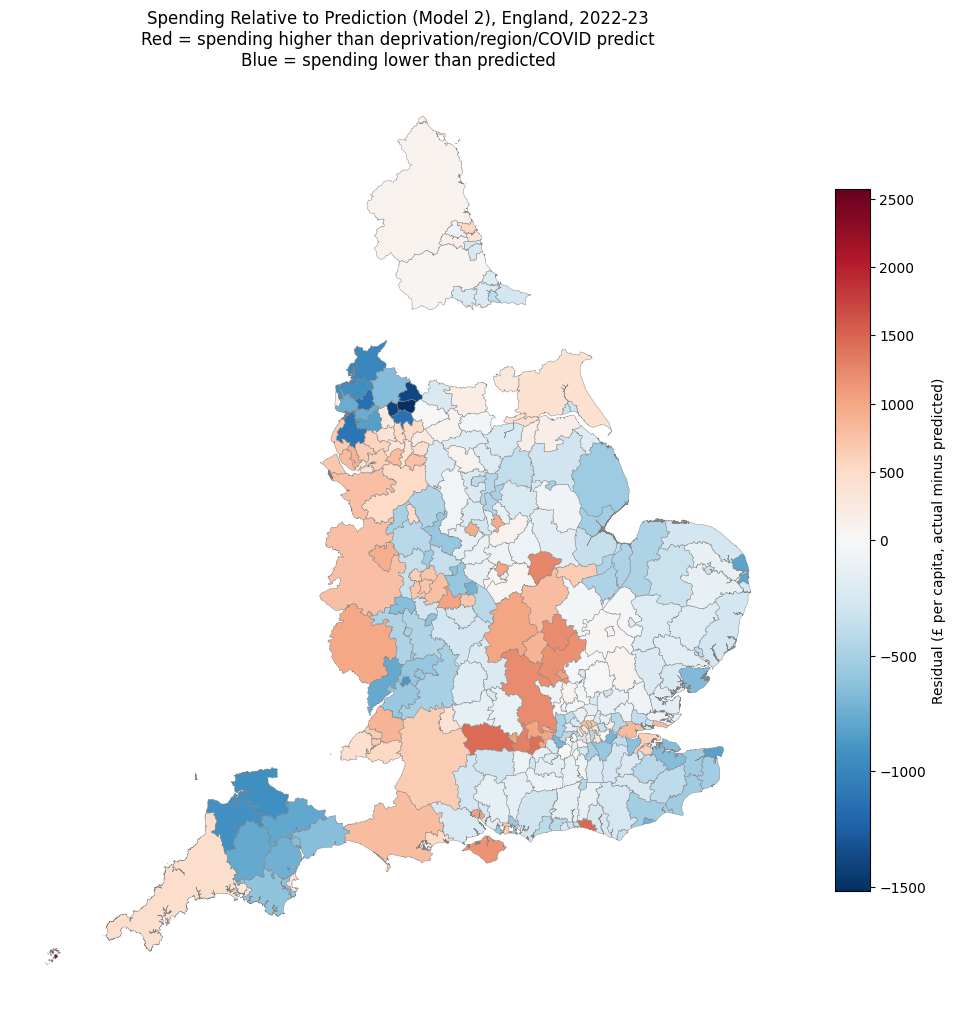

Residuals map saved


In [29]:
# ============================================================
# MAP — Model 2 Residuals (the analytically important one)
# ============================================================
# Positive = spending higher than predicted by deprivation/region/COVID
# Negative = spending lower than predicted
# Decision D27: diverging scale, midpoint fixed at zero
# ============================================================

from matplotlib.colors import TwoSlopeNorm

fig, ax = plt.subplots(1, 1, figsize=(10, 12))
norm = TwoSlopeNorm(
    vmin=gdf_map['model2_residual'].min(),
    vcenter=0,
    vmax=gdf_map['model2_residual'].max()
)
gdf_map.plot(
    column='model2_residual',
    cmap='RdBu_r',
    norm=norm,
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': 'Residual (£ per capita, actual minus predicted)', 'shrink': 0.6},
    ax=ax
)
ax.set_title('Spending Relative to Prediction (Model 2), England, 2022-23\n'
              'Red = spending higher than deprivation/region/COVID predict\n'
              'Blue = spending lower than predicted', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('map_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Residuals map saved")

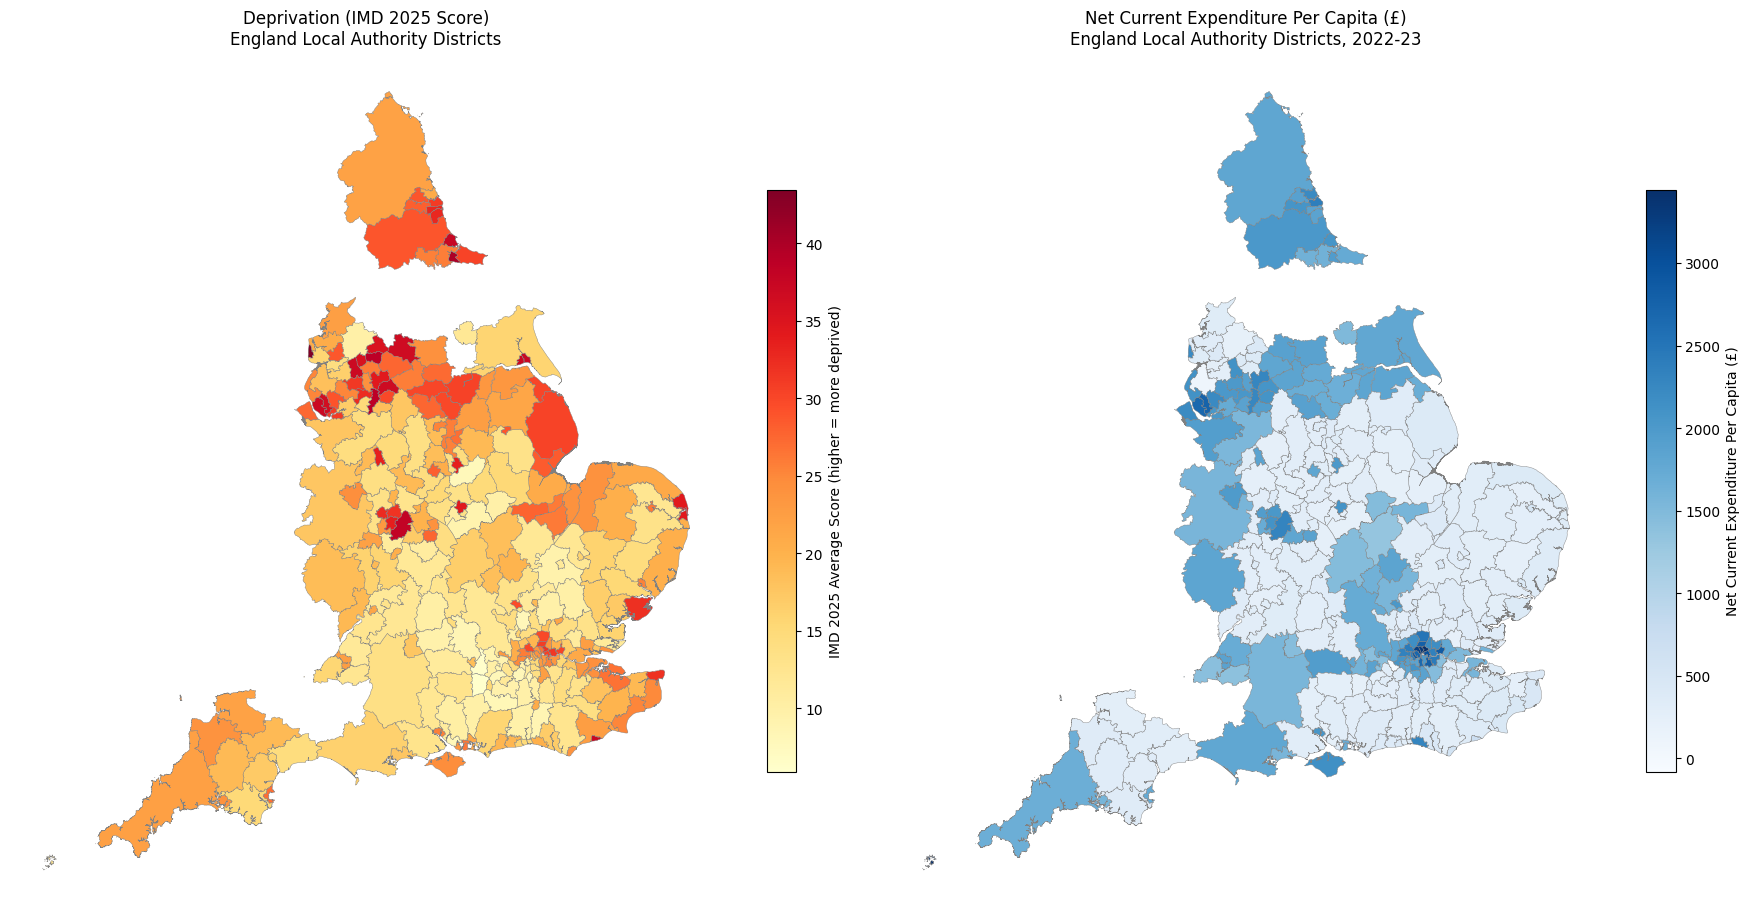

IMD and spending maps saved


In [30]:
# ============================================================
# CONTEXTUAL MAPS — IMD Score and Spending Per Capita
# ============================================================
# These provide geographic context for the residuals map
# IMD map: where is deprivation concentrated
# Spending map: where is spending concentrated
# Using 2022-23 for consistency with residuals map
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# IMD Score map
gdf_map.plot(
    column='imd_score',
    cmap='YlOrRd',
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': 'IMD 2025 Average Score (higher = more deprived)', 'shrink': 0.6},
    ax=axes[0]
)
axes[0].set_title('Deprivation (IMD 2025 Score)\nEngland Local Authority Districts', fontsize=12)
axes[0].axis('off')

# Spending per capita map
gdf_map.plot(
    column='net_current_expenditure_per_capita',
    cmap='Blues',
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': 'Net Current Expenditure Per Capita (£)', 'shrink': 0.6},
    ax=axes[1]
)
axes[1].set_title('Net Current Expenditure Per Capita (£)\nEngland Local Authority Districts, 2022-23', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('map_imd_spending.png', dpi=150, bbox_inches='tight')
plt.show()
print("IMD and spending maps saved")

In [31]:
# ============================================================
# IDENTIFY EXTREME RESIDUAL AUTHORITIES
# ============================================================
print("=== TOP 10 MOST POSITIVE RESIDUALS (spending higher than predicted) ===")
print(df_map.nlargest(10, 'model2_residual')[
    ['la_name', 'region_name', 'imd_score', 'model2_residual']
].to_string())

print("\n=== TOP 10 MOST NEGATIVE RESIDUALS (spending lower than predicted) ===")
print(df_map.nsmallest(10, 'model2_residual')[
    ['la_name', 'region_name', 'imd_score', 'model2_residual']
].to_string())

=== TOP 10 MOST POSITIVE RESIDUALS (spending higher than predicted) ===
                     la_name      region_name  imd_score  model2_residual
296          Isles of Scilly       South West     12.650      2568.033175
242       Brighton & Hove UA       South East     20.266      1482.240099
207        West Berkshire UA       South East     11.049      1458.142508
201      Bracknell Forest UA       South East     10.084      1411.046122
230             Wokingham UA       South East      6.102      1291.792918
99                Rutland UA    East Midlands      9.851      1259.259759
308               Bedford UA  East of England     19.747      1216.986501
337       Buckinghamshire UA       South East     11.921      1216.829533
314  Central Bedfordshire UA  East of England     13.102      1163.900502
260         Isle of Wight UA       South East     24.599      1162.815087

=== TOP 10 MOST NEGATIVE RESIDUALS (spending lower than predicted) ===
             la_name region_name  imd_scor

In [32]:
# Check Isles of Scilly's actual raw figures, not just the residual
print(df_reg[df_reg['la_name'].str.contains('Scilly', case=False, na=False)][
    ['lad_code', 'la_name', 'financial_year_start', 'population',
     'net_current_expenditure', 'net_current_expenditure_per_capita', 'imd_score']
].to_string())

      lad_code          la_name  financial_year_start  population  net_current_expenditure  net_current_expenditure_per_capita  imd_score
293  E06000053  Isles of Scilly                  2019        2098                   6314.0                             3009.53      12.65
294  E06000053  Isles of Scilly                  2020        2030                   7914.0                             3898.52      12.65
295  E06000053  Isles of Scilly                  2021        2271                   6950.0                             3060.33      12.65
296  E06000053  Isles of Scilly                  2022        2340                   8054.0                             3441.88      12.65
297  E06000053  Isles of Scilly                  2023        2433                  10018.0                             4117.55      12.65
298  E06000053  Isles of Scilly                  2024        2366                  11483.0                             4853.34      12.65


In [33]:
# Sanity check: total authority count and a few known figures
print(f"Total unique authorities in mart: {df_reg['lad_code'].nunique()}")
print(f"Total rows: {len(df_reg)}")

# Spot-check a familiar, large authority — Birmingham should either be
# present (pre-2023) or absent (2023-24/2024-25) per D11
print(df_reg[df_reg['la_name'].str.contains('Birmingham', case=False, na=False)][
    ['financial_year_start', 'population', 'net_current_expenditure_per_capita']
])

Total unique authorities in mart: 295
Total rows: 1727
      financial_year_start  population  net_current_expenditure_per_capita
1459                  2019     1150646                             1933.04
1460                  2020     1148692                             2094.61
1461                  2021     1143285                             2149.17
1462                  2022     1153593                             2315.25


In [34]:
# ============================================================
# SENSITIVITY — Exclude Isles of Scilly alongside City of London
# Decision D29
# ============================================================
df_reg_scilly = df_reg[df_reg['lad_code'] != 'E06000053'].copy()
print(f"Observations after also excluding Isles of Scilly: {len(df_reg_scilly)}")

model_s5 = smf.ols(
    formula='net_current_expenditure_per_capita ~ imd_score + is_covid_year_int + C(region_name)',
    data=df_reg_scilly
).fit(cov_type='cluster', cov_kwds={'groups': df_reg_scilly['lad_code']})

print(f"\nSensitivity — Isles of Scilly excluded:")
print(f"imd_score coefficient: {model_s5.params['imd_score']:.4f}")
print(f"imd_score p-value: {model_s5.pvalues['imd_score']:.4f}")
print(f"R-squared: {model_s5.rsquared:.4f}")
print(f"\nFor comparison, Model 2 (Scilly included): coefficient 35.9208, R-squared 0.5624")

Observations after also excluding Isles of Scilly: 1721

Sensitivity — Isles of Scilly excluded:
imd_score coefficient: 36.9730
imd_score p-value: 0.0000
R-squared: 0.5887

For comparison, Model 2 (Scilly included): coefficient 35.9208, R-squared 0.5624


In [39]:
print(len(df_reg))
print(model2.params['imd_score'])

1727
35.92084291561475


In [40]:
# ============================================================
# CHOROPLETH MAPS — Complete from scratch
# ============================================================
# Three maps:
# 1. Average residuals across all years (most robust)
# 2. IMD deprivation score
# 3. Spending per capita 2022-23
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import pandas as pd

# Load boundary file
gdf = gpd.read_file('/content/Local_Authority_Districts_December_2024_Boundaries_UK_BGC_7423724764112241180.geojson')
print(f"Boundary file loaded: {len(gdf)} authorities")
print(f"Columns: {list(gdf.columns[:5])}")

# Calculate residuals from Model 2
df_reg_with_resid = df_reg.copy()
df_reg_with_resid['model2_residual'] = model2.resid

# Average residual per authority across all years
mean_resid = df_reg_with_resid.groupby('lad_code')['model2_residual'].mean().reset_index()
mean_resid.columns = ['LAD24CD', 'mean_residual']

# 2022-23 data for IMD and spending maps
data_2022 = df_reg[df_reg['financial_year_start'] == 2022][
    ['lad_code', 'imd_score', 'net_current_expenditure_per_capita']
].copy()
data_2022.columns = ['LAD24CD', 'imd_score', 'spending_per_capita']

# Merge everything with boundary file
gdf_resid = gdf.merge(mean_resid, on='LAD24CD', how='inner')
gdf_imd = gdf.merge(data_2022[['LAD24CD', 'imd_score']], on='LAD24CD', how='inner')
gdf_spend = gdf.merge(data_2022[['LAD24CD', 'spending_per_capita']], on='LAD24CD', how='inner')

print(f"Residuals map: {len(gdf_resid)} authorities")
print(f"IMD map: {len(gdf_imd)} authorities")
print(f"Spending map: {len(gdf_spend)} authorities")

Boundary file loaded: 361 authorities
Columns: ['FID', 'LAD24CD', 'LAD24NM', 'LAD24NMW', 'BNG_E']
Residuals map: 295 authorities
IMD map: 291 authorities
Spending map: 291 authorities


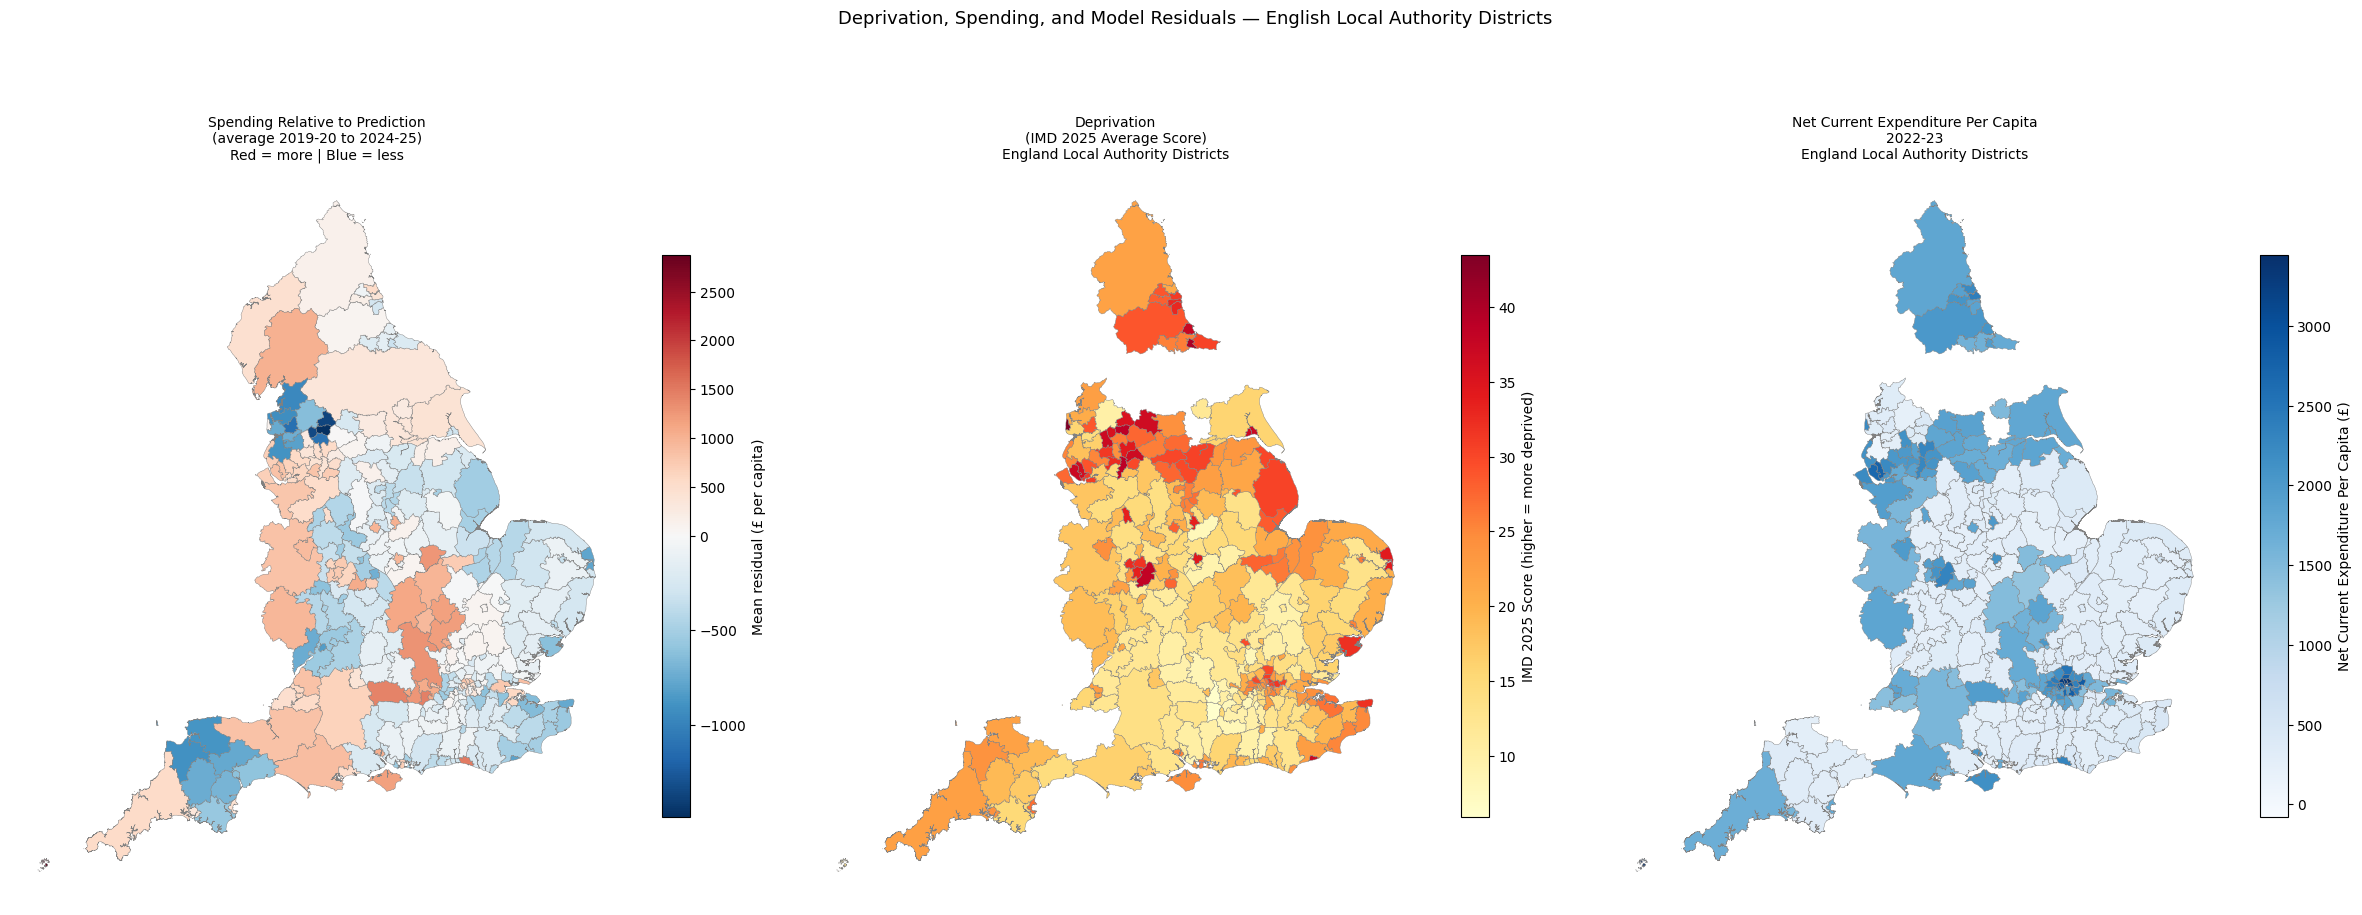

All three maps saved


In [42]:
# ============================================================
# PLOT ALL THREE MAPS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# MAP 1 — Average residuals
norm_resid = TwoSlopeNorm(
    vmin=gdf_resid['mean_residual'].min(),
    vcenter=0,
    vmax=gdf_resid['mean_residual'].max()
)
gdf_resid.plot(
    column='mean_residual',
    cmap='RdBu_r',
    norm=norm_resid,
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': 'Mean residual (£ per capita)', 'shrink': 0.6},
    ax=axes[0]
)
axes[0].set_title('Spending Relative to Prediction\n(average 2019-20 to 2024-25)\nRed = more | Blue = less', fontsize=10)
axes[0].axis('off')

# MAP 2 — IMD Score
gdf_imd.plot(
    column='imd_score',
    cmap='YlOrRd',
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': 'IMD 2025 Score (higher = more deprived)', 'shrink': 0.6},
    ax=axes[1]
)
axes[1].set_title('Deprivation\n(IMD 2025 Average Score)\nEngland Local Authority Districts', fontsize=10)
axes[1].axis('off')

# MAP 3 — Spending per capita 2022-23
gdf_spend.plot(
    column='spending_per_capita',
    cmap='Blues',
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': 'Net Current Expenditure Per Capita (£)', 'shrink': 0.6},
    ax=axes[2]
)
axes[2].set_title('Net Current Expenditure Per Capita\n2022-23\nEngland Local Authority Districts', fontsize=10)
axes[2].axis('off')

plt.suptitle('Deprivation, Spending, and Model Residuals — English Local Authority Districts', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('maps_all_three.png', dpi=150, bbox_inches='tight')
plt.show()
print("All three maps saved")